In [2]:
import networkx as nx

adjlist = 'WS-1000'
static_graph = nx.read_adjlist(f"../{adjlist}.txt", nodetype=int)
N = static_graph.number_of_nodes()
A1 = nx.to_numpy_array(static_graph, dtype=int)

beta = 0.13 # infection probability for each link
mu = 1 # Recovery probability

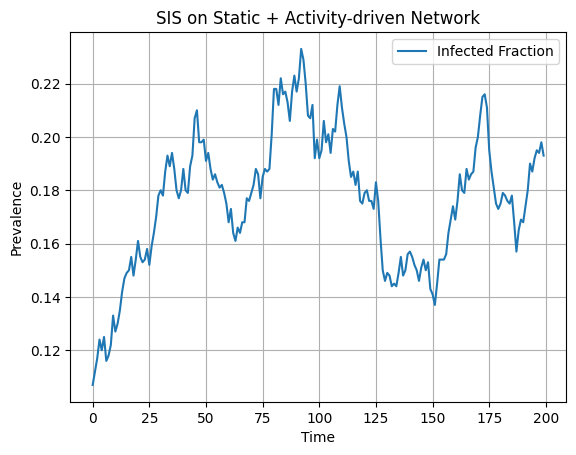

In [24]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

# === Parameters ===
beta = 0.023         # Infection rate
delta = 0.1        # Recovery rate
a = 0.1             # Activity probability per node per step
m = 10               # Links per active node
T = 200             # Simulation time steps
initial_infected_frac = 0.1

# === Load static graph ===
file_path = "../WS-1000.txt"  # <-- Update this to your file path
G = nx.read_adjlist(file_path, nodetype=int)
N = G.number_of_nodes()
nodes = list(G.nodes())

# === Initialize states ===
# 0 = Susceptible, 1 = Infected
states = np.zeros(N, dtype=int)
initial_infected = np.random.choice(N, size=int(initial_infected_frac * N), replace=False)
states[initial_infected] = 1

# === Simulation ===
prevalence = []

for t in range(T):
    new_states = states.copy()

    # Step 1: Identify active nodes and create temporal edges
    active_nodes = [i for i in range(N) if random.random() < a]
    temporal_edges = []

    for i in active_nodes:
        targets = random.sample([j for j in range(N) if j != i], m)
        for j in targets:
            temporal_edges.append((i, j))
            temporal_edges.append((j, i))  # Undirected effect

    # Step 2: Try infection
    for i in range(N):
        if states[i] == 0:  # If susceptible
            infected_neighbors = 0

            # Static neighbors
            for j in G.neighbors(i):
                if states[int(j)] == 1:
                    infected_neighbors += 1

            # Temporal neighbors
            for (src, tgt) in temporal_edges:
                if tgt == i and states[src] == 1:
                    infected_neighbors += 1

            prob_infection = 1 - (1 - beta) ** infected_neighbors
            if random.random() < prob_infection:
                new_states[i] = 1

    # Step 3: Recovery
    for i in range(N):
        if states[i] == 1 and random.random() < delta:
            new_states[i] = 0

    states = new_states
    prevalence.append(np.sum(states) / N)

# === Plot ===
plt.plot(prevalence, label="Infected Fraction")
plt.xlabel("Time")
plt.ylabel("Prevalence")
plt.title("SIS on Static + Activity-driven Network")
plt.grid(True)
plt.legend()
plt.show()


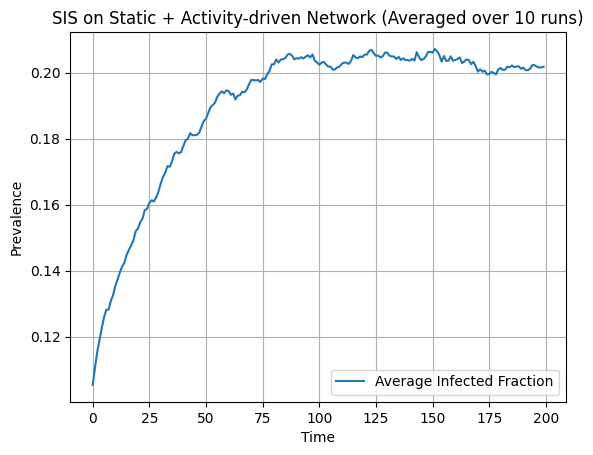

In [29]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

def run_sis_simulation(
    G,
    beta=0.025,
    delta=0.1,
    a=0.1,
    m=5,
    T=200,
    initial_infected_frac=0.1,
    seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    N = G.number_of_nodes()
    states = np.zeros(N, dtype=int)

    initial_infected = np.random.choice(N, size=int(initial_infected_frac * N), replace=False)
    states[initial_infected] = 1

    prevalence = []

    for t in range(T):
        new_states = states.copy()

        # Temporal layer generation
        active_nodes = [i for i in range(N) if random.random() < a]
        temporal_edges = []
        for i in active_nodes:
            targets = random.sample([j for j in range(N) if j != i], min(m, N - 1))
            for j in targets:
                temporal_edges.append((i, j))
                temporal_edges.append((j, i))

        # Infection process
        for i in range(N):
            if states[i] == 0:  # Susceptible
                infected_neighbors = 0
                for j in G.neighbors(i):
                    if states[int(j)] == 1:
                        infected_neighbors += 1
                for (src, tgt) in temporal_edges:
                    if tgt == i and states[src] == 1:
                        infected_neighbors += 1
                prob_infection = 1 - (1 - beta) ** infected_neighbors
                if random.random() < prob_infection:
                    new_states[i] = 1

        # Recovery process
        for i in range(N):
            if states[i] == 1 and random.random() < delta:
                new_states[i] = 0

        states = new_states
        prevalence.append(np.sum(states) / N)

    return prevalence


# === Load static graph ===
file_path = "../WS-1000.txt"  # Update if needed
G = nx.read_adjlist(file_path, nodetype=int)

# === Run multiple simulations and average
runs = 100
all_prevalences = []

for run in range(runs):
    prevalence = run_sis_simulation(G, beta=0.03*2, delta=0.1*2, a=0.1, m=5, T=200, seed=run)
    all_prevalences.append(prevalence)

avg_prevalence = np.mean(all_prevalences, axis=0)

# === Plot
plt.plot(avg_prevalence, label="Average Infected Fraction")
plt.xlabel("Time")
plt.ylabel("Prevalence")
plt.title("SIS on Static + Activity-driven Network (Averaged over 10 runs)")
plt.grid(True)
plt.legend()
plt.show()


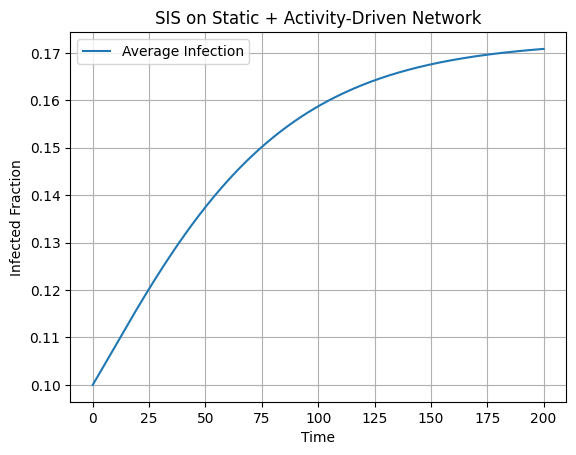

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import networkx as nx

# === Parameters ===
N = 1000            # Number of nodes
delta = 0.1        # Recovery rate
beta = 0.020         # Infection rate
a = 0.1             # Activity rate
m = 10               # Links per active node
T = 200             # Total time
rho0 = 0.1         # Initial fraction of infected

# === Generate static graph ===
adjlist = 'WS-1000'
G = nx.read_adjlist(f"../{adjlist}.txt", nodetype=int)

# G = nx.watts_strogatz_graph(N, k=10, p=0.1)
adj_matrix = nx.to_numpy_array(G)
degree_vector = np.sum(adj_matrix, axis=1)

# === Mean-field ODE system ===
def sis_multiplex_ode(rho, t, beta, delta, adj_matrix, a, m):
    N = len(rho)
    avg_rho = np.mean(rho)
    drho_dt = np.zeros(N)

    for i in range(N):
        static_term = beta * np.sum(adj_matrix[i] * rho)
        temporal_term = beta * a * m * (rho[i] + avg_rho)
        infection_term = (1 - rho[i]) * (static_term + temporal_term)
        recovery_term = -delta * rho[i]
        drho_dt[i] = recovery_term + infection_term

    return drho_dt

# === Initial condition ===
rho_init = np.full(N, rho0)

# === Time vector ===
time = np.linspace(0, T, T)

# === Solve ODE ===
solution = odeint(sis_multiplex_ode, rho_init, time, args=(beta, delta, adj_matrix, a, m))
avg_prevalence = np.mean(solution, axis=1)

# === Plot ===
plt.plot(time, avg_prevalence, label="Average Infection")
plt.xlabel("Time")
plt.ylabel("Infected Fraction")
plt.title("SIS on Static + Activity-Driven Network")
plt.grid(True)
plt.legend()
plt.show()


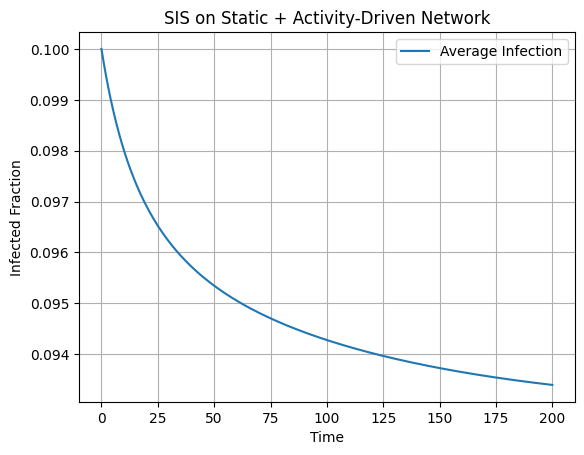

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import networkx as nx

# === Parameters ===
N = 1000            # Number of nodes
delta = 0.1        # Recovery rate
beta = 0.027         # Infection rate
a = 0.1             # Activity rate
m = 0               # Links per active node
T = 200             # Total time
rho0 = 0.1         # Initial fraction of infected

# === Generate static graph ===
adjlist = 'WS-1000'
G = nx.read_adjlist(f"../{adjlist}.txt", nodetype=int)

# G = nx.watts_strogatz_graph(N, k=10, p=0.1)
adj_matrix = nx.to_numpy_array(G)
degree_vector = np.sum(adj_matrix, axis=1)

# === Mean-field ODE system ===
def sis_multiplex_ode(rho, t, beta, delta, adj_matrix, a, m):
    N = len(rho)
    avg_rho = np.mean(rho)
    drho_dt = np.zeros(N)

    for i in range(N):
        static_term = beta * np.sum(adj_matrix[i] * rho)
        temporal_term = beta * a * m * (rho[i] + avg_rho)
        infection_term = (1 - rho[i]) * (static_term + temporal_term)
        recovery_term = -delta * rho[i]
        drho_dt[i] = recovery_term + infection_term

    return drho_dt

# === Initial condition ===
rho_init = np.full(N, rho0)

# === Time vector ===
time = np.linspace(0, T, T)

# === Solve ODE ===
solution = odeint(sis_multiplex_ode, rho_init, time, args=(beta, delta, adj_matrix, a, m))
avg_prevalence = np.mean(solution, axis=1)

# === Plot ===
plt.plot(time, avg_prevalence, label="Average Infection")
plt.xlabel("Time")
plt.ylabel("Infected Fraction")
plt.title("SIS on Static + Activity-Driven Network")
plt.grid(True)
plt.legend()
plt.show()
